## 特征值和SVD

### outline
- 特征值与特征向量
    1. 从线性变换理解特征向量
    2. 特征值与特征向量的定义
    3. 几何意义

- 特征值的基本性质
    1. 特征值与 det
    2. 特征值之和与迹
    3. 特征值与矩阵幂
    4. 特征值分解
    5. 对角化及成立条件
    6. 相似矩阵

- 特殊矩阵：对称矩阵
    1. 特征值为实数
    2. 不同特征值对应的特征向量正交
    3. 谱分解 A = $QΛQ^T$

- 二次型
    1. $x^TAx$ 的几何意义
    2. 二次型与特征值
    3. 正定/半正定/负定

- SVD
    1. 为什么需要 SVD
    2. A = $U\Sigma V^T$
    3. 几何意义
    4. 奇异值从哪里来
    5. 与特征值的关系
    6. 对称矩阵下 SVD 与特征分解的关系

- PCA的桥梁
    1. 协方差矩阵
    2. 为什么 PCA 会出现特征值
    3. 为什么最大特征值对应主成分
    4. PCA 与 SVD 的关系

In [4]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

### 特征值与特征向量
1. 从线性变换理解特征向量
在之前学习线性代数我看到Ax这样的矩阵和向量相乘就默认会对它进行数值运算而忽略其背后的几何含义，其实像这样的矩阵乘法可以理解成一个线性变化x->Ax，对x向量进行旋转，拉伸，压缩，剪切，反射等变化。不难发现原向量经过线性变化后，都会发生变化，要么方向进行变化要么长度要没两者都进行了变化。

In [ ]:
# 线性变化图 todo

可以通过下图发现，矩阵A对下面的向量组进行转换，有些向量方向并没有改变只是向量的长度发生了变化。这里就发现一个有意思的现象，虽然矩阵对大多数方向的行为很复杂，但空间中存在一些特殊方法，矩阵作用在这些方向上，只做简单的缩放
$$Ax=\lambda x$$
- x这个是特殊方向，称为特征向量
- $\lambda$这个缩放倍数，称为特征值
> 特征向量是在线性变换下保持其一维子空间不变的特殊方向；矩阵在这个方向上的作用被简化为单纯的缩放。

特征向量方向不变只是几何解释，因为$Ax=\lambda x$说明Ax与x线性相关$Ax \in span(x)$，A把向量转换后，仍落在自己张成的一维空间里。

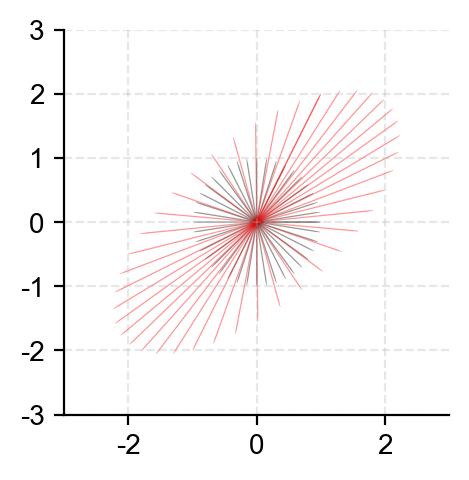

In [ ]:
theta=np.linspace(0,2*np.pi,41)
x,y=np.cos(theta),np.sin(theta)
A=np.array([[1,2],[2,0.5]])
o=np.zeros_like(x)
fig,ax=plt.subplots()
ax.quiver(o,o,x,y,scale=1,          # 【核心】调大这个数，箭头就会变小
          scale_units='xy', # 配合 scale 使用，保证缩放一致
          width=0.02,      # 调小这个数，箭杆变细
          headwidth=0.5,    # 箭头头部宽度
          headlength=0.5,   # 箭头头部长度
          angles='xy',
          units='xy',
          alpha=0.4,)
X=np.column_stack([x,y])
Y=A@np.row_stack([x,y])
ax.quiver(o,o,Y[0],Y[1],scale=1,          # 【核心】调大这个数，箭头就会变小
          scale_units='xy', # 配合 scale 使用，保证缩放一致
          width=0.02,      # 调小这个数，箭杆变细
          headwidth=0.5,    # 箭头头部宽度
          headlength=0.5,   # 箭头头部长度
          angles='xy',
          units='xy',
          color='r',
          alpha=0.4,)
ax.set_xlim(-3,3)
ax.set_ylim(-3,3)
ax.set_aspect('equal')

2. 特征值与特征向量的定义
设A是n阶方阵，x为非零向量，若存在数$\lambda$使得下式成立：$Ax=\lambda x$，那么将数$\lambda$称为特征值，非零向量x称为A的对应于$\lambda$的特征向量（$\lambda 可以为0的，比如投影矩阵$）。上面式子表示了矩阵A与它的特征向量相乘它的方向不会发生改变始终与x平行，乘出来的特征值则告诉了我们这个特征向量是伸张/缩放/方向转变。

计算过程：
$$Ax=\lambda x$$
- 先在右边$\lambda x$乘单位向量I(这对应于常数的乘1操作，对应的值不会改变),在移至右边
$$Ax-\lambda Ix=0$$

$$(A-\lambda I)x=0$$
- 化简乘上述的式子后，在列出对应的行列式让其等于0（因为特征向量不为0），解出$\lambda$的值。这个方程式称特征多项式
$$det(A-\lambda I)=0$$

- 把 $ \lambda$代入$(A-\lambda I)x=0$，求出$(A-\lambda I)$的0空间



3. 几何意义
特征值特征向量刻画了矩阵变化的空间特征，怎么来理解这句呢。上面说了矩阵A背后蕴含了一个几何形状变化，在这个A矩阵描述的变化中，它的特征向量与A矩阵相乘方向是没有发生变化始终平行。数学家就想了聪明的办法，借助这个不变性来构造一个变化矩阵。比如$x \in R^2 $，矩阵A的特征向量为$\{v_1,v_2\}$，原始向量为x，Ax表示x几何变化后的新向量。这里x可以由A矩阵的特征向量来线性组合而成$x=c_1v_1+c_2v_2$ (x=Vc $c=V^{-1}x$，c原坐标系x，转换坐标后在新坐标系上的系数)，由于v是A矩阵的特征向量，所以$Ax=A(c_1v_1+c_2v_2)=c_1\lambda_1v_1+c_2\lambda_2v_2$。这里发现我们原来的坐标底地$(e_1,e_2)$转换为A的特征基底后，矩阵的变化，就变成了在特征基地上的伸缩变化。

### 特征值的基本性质
#### 1. 特征值与 det、特征值之和与迹

上面介绍了特征多项式，通过它来求$\lambda$的值。这里我们看看它的两个性质（以3维空间为例）
$$
\det(A) = \lambda_1\lambda_2\lambda_3
$$
$$
\operatorname{tr}(A) = a_{11} + a_{22} + a_{33} = \lambda_1 + \lambda_2 + \lambda_3
$$

证明：
3x3矩阵为：
$$A = \begin{pmatrix} a_{11} & a_{12} & a_{13} \\ a_{21} & a_{22} & a_{23} \\ a_{31} & a_{32} & a_{33} \end{pmatrix}$$
1. 列出特征多项式
$$\lambda I - A = \begin{pmatrix} \lambda - a_{11} & -a_{12} & -a_{13} \\ -a_{21} & \lambda - a_{22} & -a_{23} \\ -a_{31} & -a_{32} & \lambda - a_{33} \end{pmatrix}$$
按照Laplaca展开后
$$p(\lambda) = (\lambda - a_{11}) M_{11} - (-a_{12}) M_{12} + (-a_{13}) M_{13}$$
$$p(\lambda) = (\lambda - a_{11}) \begin{vmatrix} \lambda - a_{22} & -a_{23} \\ -a_{32} & \lambda - a_{33} \end{vmatrix} + a_{12} \begin{vmatrix} -a_{21} & -a_{23} \\ -a_{31} & \lambda - a_{33} \end{vmatrix} - a_{13} \begin{vmatrix} -a_{21} & \lambda - a_{22} \\ -a_{31} & -a_{32} \end{vmatrix}$$

2. 继续展开代入
$$\begin{aligned} M_{11} &= (\lambda - a_{22})(\lambda - a_{33}) - (-a_{23})(-a_{32}) \\ &= \lambda^2 - (a_{22} + a_{33})\lambda + a_{22}a_{33} - a_{23}a_{32} \end{aligned}$$
代入 $(\lambda - a_{11})$ 
$$\begin{aligned} (\lambda - a_{11}) M_{11} &= (\lambda - a_{11}) \left[ \lambda^2 - (a_{22} + a_{33})\lambda + (a_{22}a_{33} - a_{23}a_{32}) \right] \\ &= \lambda^3 - (a_{22} + a_{33})\lambda^2 + (a_{22}a_{33} - a_{23}a_{32})\lambda \\ &\quad - a_{11}\lambda^2 + a_{11}(a_{22} + a_{33})\lambda - a_{11}(a_{22}a_{33} - a_{23}a_{32}) \end{aligned}$$
依此内推第2个式子：
$$\begin{aligned} M_{12} &= (-a_{21})(\lambda - a_{33}) - (-a_{23})(-a_{31}) \\ &= -a_{21}\lambda + a_{21}a_{33} - a_{23}a_{31} \end{aligned}$$
$$a_{12} M_{12} = -a_{12}a_{21}\lambda + (a_{12}a_{21}a_{33} - a_{12}a_{23}a_{31})$$
第3个式子：
$$\begin{aligned} M_{13} &= (-a_{21})(-a_{32}) - (\lambda - a_{22})(-a_{31}) \\ &= a_{21}a_{32} + a_{31}\lambda - a_{22}a_{31} \end{aligned}$$
$$-a_{13} M_{13} = -a_{13}a_{31}\lambda - (a_{13}a_{21}a_{32} - a_{13}a_{22}a_{31})$$

3. 合并所有项，按$\lambda$降幂排列
- $\lambda^3$ 项系数： $c_3 = 1$
-  $\lambda^2$ 项系数：$c_2 = -(a_{11} + a_{22} + a_{33})$
-  $\lambda^1$ 项系数：$\begin{aligned} c_1 &= (a_{11}a_{22} + a_{11}a_{33} + a_{22}a_{33} - a_{23}a_{32}) - a_{12}a_{21} - a_{13}a_{31} \\ &= (a_{11}a_{22} - a_{12}a_{21}) + (a_{11}a_{33} - a_{13}a_{31}) + (a_{22}a_{33} - a_{23}a_{32}) \end{aligned}$
> $\begin{vmatrix} a_{11} & a_{12} \\ a_{21} & a_{22} \end{vmatrix} = a_{11}a_{22} - a_{12}a_{21}$都是 $A$ 的三个 2阶主子式 之和

- $\lambda^0$ 项系数：$$\begin{aligned} \det(A) &= a_{11}(a_{22}a_{33} - a_{23}a_{32}) - a_{12}(a_{21}a_{33} - a_{23}a_{31}) + a_{13}(a_{21}a_{32} - a_{22}a_{31}) \\ &= a_{11}a_{22}a_{33} - a_{11}a_{23}a_{32} - a_{12}a_{21}a_{33} + a_{12}a_{23}a_{31} + a_{13}a_{21}a_{32} - a_{13}a_{22}a_{31} \end{aligned}$$
> det(A)

4. 综合特征多项式
$$p(\lambda) = \lambda^3 - \operatorname{tr}(A)\lambda^2 + M\lambda - \det(A)$$
有代数基本定义，若A的特征值为 $\lambda_1, \lambda_2, \lambda_3$，则多项式因式分解为：$$p(\lambda) = (\lambda - \lambda_1)(\lambda - \lambda_2)(\lambda - \lambda_3)$$
然后对比对应项系数
$$p(\lambda) = \lambda^3 - (\lambda_1 + \lambda_2 + \lambda_3)\lambda^2 + (\lambda_1\lambda_2 + \lambda_2\lambda_3 + \lambda_3\lambda_1)\lambda - \lambda_1\lambda_2\lambda_3$$

#### 2. 特征值分解
假设一个矩阵nxn的A存在n个不同特征值（表明它所有特征向量线性独立），现在把所有特征向量和特征值都写成矩阵乘法
$$
A \begin{bmatrix} x_1 & x_2 & \dots & x_n \end{bmatrix} = \begin{bmatrix} \lambda_1 x_1 & \lambda_2 x_2 & \dots & \lambda_n x_n \end{bmatrix}
$$
接下来在把右边的矩阵拆开
$$ 
A \begin{bmatrix} x_1 & x_2 & \dots & x_n \end{bmatrix} = \begin{bmatrix} x_1 & x_2 & \dots & x_n \end{bmatrix} \begin{bmatrix} \lambda_1 & & & \\ & \lambda_2 & & \\ & & \ddots & \\ & & & \lambda_n \end{bmatrix}
$$ 
然后上面的式子简写成$ AS = S \Lambda$
由于X中向量都是线性独立所以X是可逆的，所以矩阵A就可以分解为这样形式$ A= S \Lambda S^{-1} $。当一个矩阵能分解$ A= S \Lambda S^{-1} $，称A可对角化。

#### 3. 成立条件
上面看到了矩阵A通过特征值进行矩阵分解，那这节就来说明上诉对角化成立的条件，以2x2矩阵为例
- 充分条件 <= 若有2个线性无关的特征向量
设$x_1, x_2$ 为 $A$ 的两个特征向量，分别对应特征值 $\lambda_1, \lambda_2$，满足：
$$Ax_1 = \lambda_1 x_1, \quad Ax_2 = \lambda_2 x_2$$
构造矩阵 $S = \begin{bmatrix} x_1 & x_2 \end{bmatrix}$。因为 $x_1, x_2$ 线性无关，$S$ 的两列不共线，所以 $\det(S) \neq 0$，$S$ 可逆（$S^{-1}$ 存在）。
$$AS = A \begin{bmatrix} x_1 & x_2 \end{bmatrix} = \begin{bmatrix} Ax_1 & Ax_2 \end{bmatrix} = \begin{bmatrix} \lambda_1 x_1 & \lambda_2 x_2 \end{bmatrix} = \begin{bmatrix} x_1 & x_2 \end{bmatrix} \begin{bmatrix} \lambda_1 & 0 \\ 0 & \lambda_2 \end{bmatrix} = S \Lambda$$


- 必要性 => 若能对角化，则必有两个线性无关的特征向量
假设存在可逆矩阵 $S$ 使得 $S^{-1}AS = \Lambda = \begin{bmatrix} \lambda_1 & 0 \\ 0 & \lambda_2 \end{bmatrix}$。
两端左乘 $S$，得：$$AS = S\Lambda$$
将可逆矩阵 $S$ 按列切分为两个列向量 $S = \begin{bmatrix} v_1 & v_2 \end{bmatrix}$：$$A \begin{bmatrix} v_1 & v_2 \end{bmatrix} = \begin{bmatrix} v_1 & v_2 \end{bmatrix} \begin{bmatrix} \lambda_1 & 0 \\ 0 & \lambda_2 \end{bmatrix}$$展开后逐列对应：$$Av_1 = \lambda_1 v_1, \quad Av_2 = \lambda_2 v_2$$
因为 $S$ 是可逆矩阵，其列向量 $v_1, v_2$ 必须非零且线性无关。

通过上面发现nxn的矩阵对角化，必须要有n个特征向量，那什么决定特征向量的个数是足够的呢？

答案就与特征值有关，当有n个不同的特征值时，矩阵必定能对角化

证明
假设存在标量 $c_1, c_2$ 使得：
$$c_1 x_1 + c_2 x_2 = 0 \tag{1}$$
等式两边左乘 $A$：
$$c_1 A x_1 + c_2 A x_2 = 0 \implies c_1 \lambda_1 x_1 + c_2 \lambda_2 x_2 = 0 \tag{2}$$
整合(1)(2)式子

$$
\begin{cases}
c_1 \lambda_1 x_1 + c_2 \lambda_1 x_2 = 0 \\
c_1 x_1 + c_2 x_2 = 0 \tag{1}
\end{cases}
$$
的出$c_2 (\lambda_2 - \lambda_1) x_2 = 0$，因为特征向量 $x_2 \neq 0$ 且特征值互异 $\lambda_2 - \lambda_1 \neq 0$，所以必须有 $c_2 = 0$，同理可得 $c_1 = 0$。因此 $x_1, x_2$ 必然线性无关，矩阵必定可以对角化



#### 4. 特征值与矩阵幂
当A为一个可对角化矩阵，它的$A^k$可以分解为
$$A^k=S\Lambda S^{-1} S\Lambda S^{-1} S\Lambda S^{-1} ...$$
因$SS^{-1}=I$所以$A^k=S\Lambda ^k S^{-1}$


关于$A^{-1}x=\frac{1}{\lambda}x$
证明：
$$
Ax=\lambda x 
$$
两边同时乘$A^{-1}$
$$
A^{-1}Ax=\lambda A^{-1}x \implies  x= \lambda A^{-1}x  \implies A^{-1}x=\frac{1}{\lambda}x
$$



5. 相似矩阵
定义：$B=S^{-1}AS$其中S可逆，那么称A~B，即A和B相似。与特征分解联系起来$A=S\Lambda S^{-1}$两边同时乘$S^{-1}AS=\Lambda$所以A~$\Lambda$。
相似矩阵可以看作换坐标系，假设x是原坐标系中的向量，换一套基底x=$Sx_1$，$x_1$为新坐标系，原来的现象变化就变成Ax=$ASx_1$，为了讲结果在新坐标系中表示在$S^{-1}$，所以新坐标系中的矩阵为$S\Lambda S^{-1}$。
可以总结为一句话，相似矩阵不是两个不同完全不同的线性变化，而是同一个线性变化在不同坐标系下的矩阵表示。

### 对称矩阵
1. 特征值为实数
2. 不同特征值对应的特征向量正交
3. 谱分解 A = QΛQᵀ


### 二次型
1. $x^TAx$ 的几何意义
2. 二次型与特征值
3. 正定/半正定/负定

### SVD
1. 为什么需要 SVD
前面讲了对一个矩阵做特征值分解能得到一些很好的性质，可以把复杂矩阵变化转变为成在特征向量为基底的坐标系进行缩放然后换回原来基底。但做这一切都是有个前提A必须是nxn且它们特征向量都不同。也就是说特征分解主要研究方阵 $(A: R^n \to R^n )$ 自身的特殊方向；对于不同的输入输出空间就失效了，而SVD 则把这种思想推广到任意矩阵 $(A: R^n\to R^m)$。

2. A = $U\Sigma V^T$
SVD 不要求输入空间和输出空间具有相同维度，因此不再要求变换后的特殊方向与原方向重合，而是寻找输入空间中的特殊方向 $(v_i)$，使其经过 $(A)$ 后变成输出空间中的特殊方向 $(u_i)$。
$$A=U\Sigma V$$
- $(v_i)$ 输入空间中特殊方向
- $(u_i)$ 输出空间中特殊方向
- $\sigma$ 方向被拉伸了多少

3. 几何意义
SVD的几何意义和特征值分解的很相似
$$A=S\Lambda S^{-1}$$
原坐标系->特征坐标系->伸缩->原坐标
$$A = U\Sigma V^T$$
输入空间->输入特殊坐标->伸缩->输出特殊坐标

SVD 可以看成把一个任意的线性变换拆成：输入空间的正交坐标变换 + 各方向独立缩放 + 输出空间的正交坐标变换。

4. 奇异值从哪里来
假设一个2x3的矩阵A，想找一个向量x在R^3上并且长度||x||=1，使得||Ax||的值最大
||Ax||^2=$(Ax)^TAx=x^TA^TAx$，$A^TA$是一个2x2的对称矩阵，$x^TA^TAx$为二次型结果可以判断一下性质
1. $||Ax||^2=x^TA^TAx >=0$，x不是零向量所以$A^TA$是一个半正定矩阵，他的特征值大于等于0 
2. $A^TA$相互垂直可对角化,$A^TAv_i=\lambda_i v_i$
结合上面性质得到
$$||Ax||^2=x^TA^TAx=x^TV\Lambda V^Tx=(V^Tx)^T \Lambda (V^Tx)$$
设y=$v^Tx$

$$
||Ax||=y^T \Lambda y
$$ 
因为||x||=1，$ ||y||^2=(V^Tx)^T(V^Tx) =x^TV V^Tx,V V^T=I$所以||y||=1
$$
||Ax||^2=y^T \Lambda y =  \lambda_1 y_1^2 + \lambda_2 y_2^2 
$$ 
所以||Ax||的最大值是$\sqrt{\lambda_i}$。这个值便称为A的奇异值


5. 与特征值的关系
根据上面证明A为一个nxm的矩阵它的的奇异值是$\sqrt{\lambda_i}$，$\lambda_i$是$A^TA$矩阵的特征值

6. 对称矩阵下 SVD 与特征分解的关系
通过上面证明我们发现对于一个nxm的矩阵，可以选择特殊向量与矩阵相乘会得到以下这关系，
$$
Av_i=\sigma u_1
$$
$v_i$为$A^TA$的特征向量，$A^TA$又是对称向量所以它可以对角化,用$v_i$构成一个nxn的矩阵，写成如下形式
$$
AV= U \Sigma
$$
V是可逆另外$V^T=V^{-1}$，所以
$$
A= U \Sigma V^T
$$
注意$v_i$之间是相互垂直的，在作用矩阵$Av_i$后的向量$u_i$也是相互垂直
证明
$$v_iv_j=0$$

$$(Av_j)^T(Av_j)=v_j^TA^TAv_i=\lambda_i v_j v_i =0$$

$$v_iv_j=0$$

